# AML — Visualizations

Standalone visualization notebook for the AML Risk Detection project.  
All data, model, and evaluation logic lives in `src/` — this notebook only calls those functions and renders plots.

**Sections:**
1. Data Loading & Preparation
2. Dataset Overview
3. Transaction Amount Distributions
4. Time Series Patterns
5. Model Training
6. Evaluation Curves
7. PCA Projection

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    build_feature_matrix,
    build_transaction_graph,
    clean_czech,
    clean_ibm,
    harmonize,
    load_czech,
    load_ibm,
    parse_ibm_patterns,
)
from src.models import (
    compute_ensemble_scores,
    train_autoencoder,
    train_isolation_forest,
    train_kmeans,
)
from src.evaluate import plot_pr_roc_curves, plot_pca_projection

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_SEED = 42
print(f'Device: {DEVICE}')

Device: cpu


## 1. Data Loading & Preparation

In [2]:
ibm_raw     = load_ibm()
czech_raw   = load_czech()

ibm_clean   = clean_ibm(ibm_raw)
czech_clean = clean_czech(czech_raw)

merged = harmonize(ibm_clean, czech_clean)

ibm_d = merged[merged['source'] == 'ibm'].copy()
cz_d  = merged[merged['source'] == 'czech'].copy()

print(f'Merged : {merged.shape[0]:,} rows')
print(f'IBM    : {len(ibm_d):,}  |  Laundering: {(ibm_d["_label"]==1).sum():,}')
print(f'Czech  : {len(cz_d):,}  |  Default:    {(cz_d["_label"]==1).sum():,}')

Merged : 6,134,656 rows
IBM    : 5,078,336  |  Laundering: 5,177
Czech  : 1,056,320  |  Default:    22,760


## 2. Dataset Overview

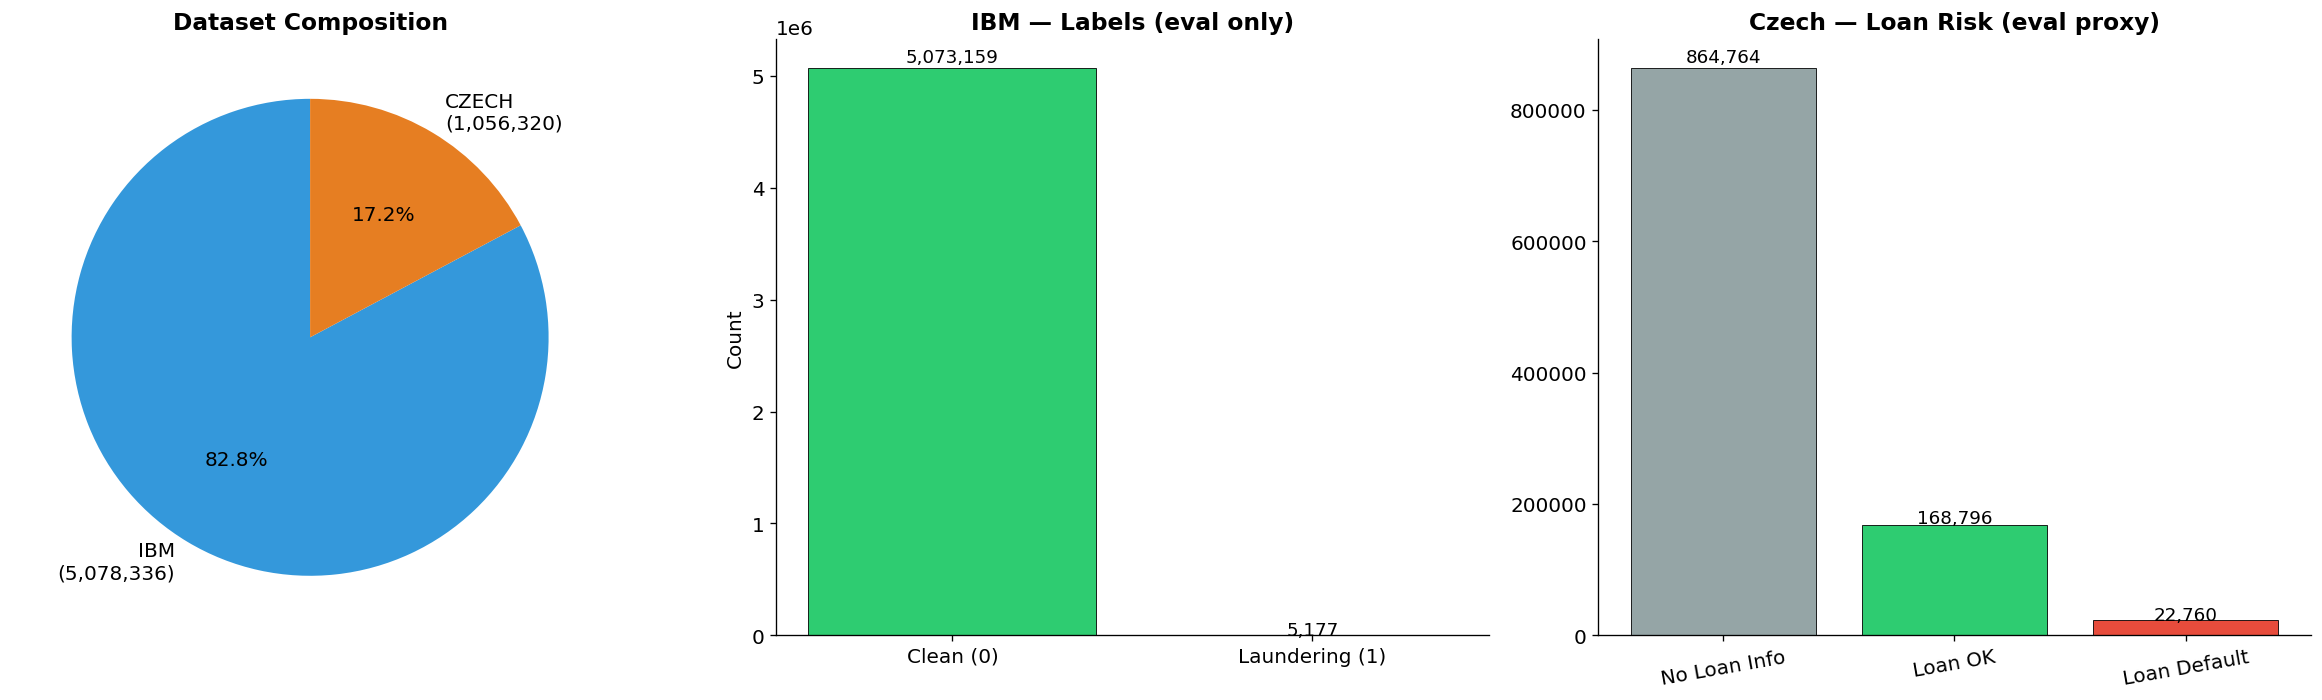

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Source split
ax = axes[0]
src = merged['source'].value_counts()
ax.pie(src.values, labels=[f"{k.upper()}\n({v:,})" for k,v in src.items()],
       colors=['#3498db','#e67e22'], autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
ax.set_title('Dataset Composition', fontsize=14, fontweight='bold')

# IBM target
ax = axes[1]
lbl = ibm_d['_label'].value_counts().sort_index()
bars = ax.bar(['Clean (0)','Laundering (1)'], lbl.values,
              color=['#2ecc71','#e74c3c'], edgecolor='black', linewidth=0.5)
for b, v in zip(bars, lbl.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f'{v:,}', ha='center', fontsize=11)
ax.set_title('IBM — Labels (eval only)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')

# Czech risk
ax = axes[2]
cl = cz_d['_label'].value_counts().sort_index()
nm  = {-1:'No Loan Info', 0:'Loan OK', 1:'Loan Default'}
clr = {-1:'#95a5a6', 0:'#2ecc71', 1:'#e74c3c'}
bars = ax.bar([nm.get(k, str(k)) for k in cl.index], cl.values,
              color=[clr.get(k, '#aaa') for k in cl.index],
              edgecolor='black', linewidth=0.5)
for b, v in zip(bars, cl.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f'{v:,}', ha='center', fontsize=11)
ax.set_title('Czech — Loan Risk (eval proxy)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('viz1_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Transaction Amount Distributions

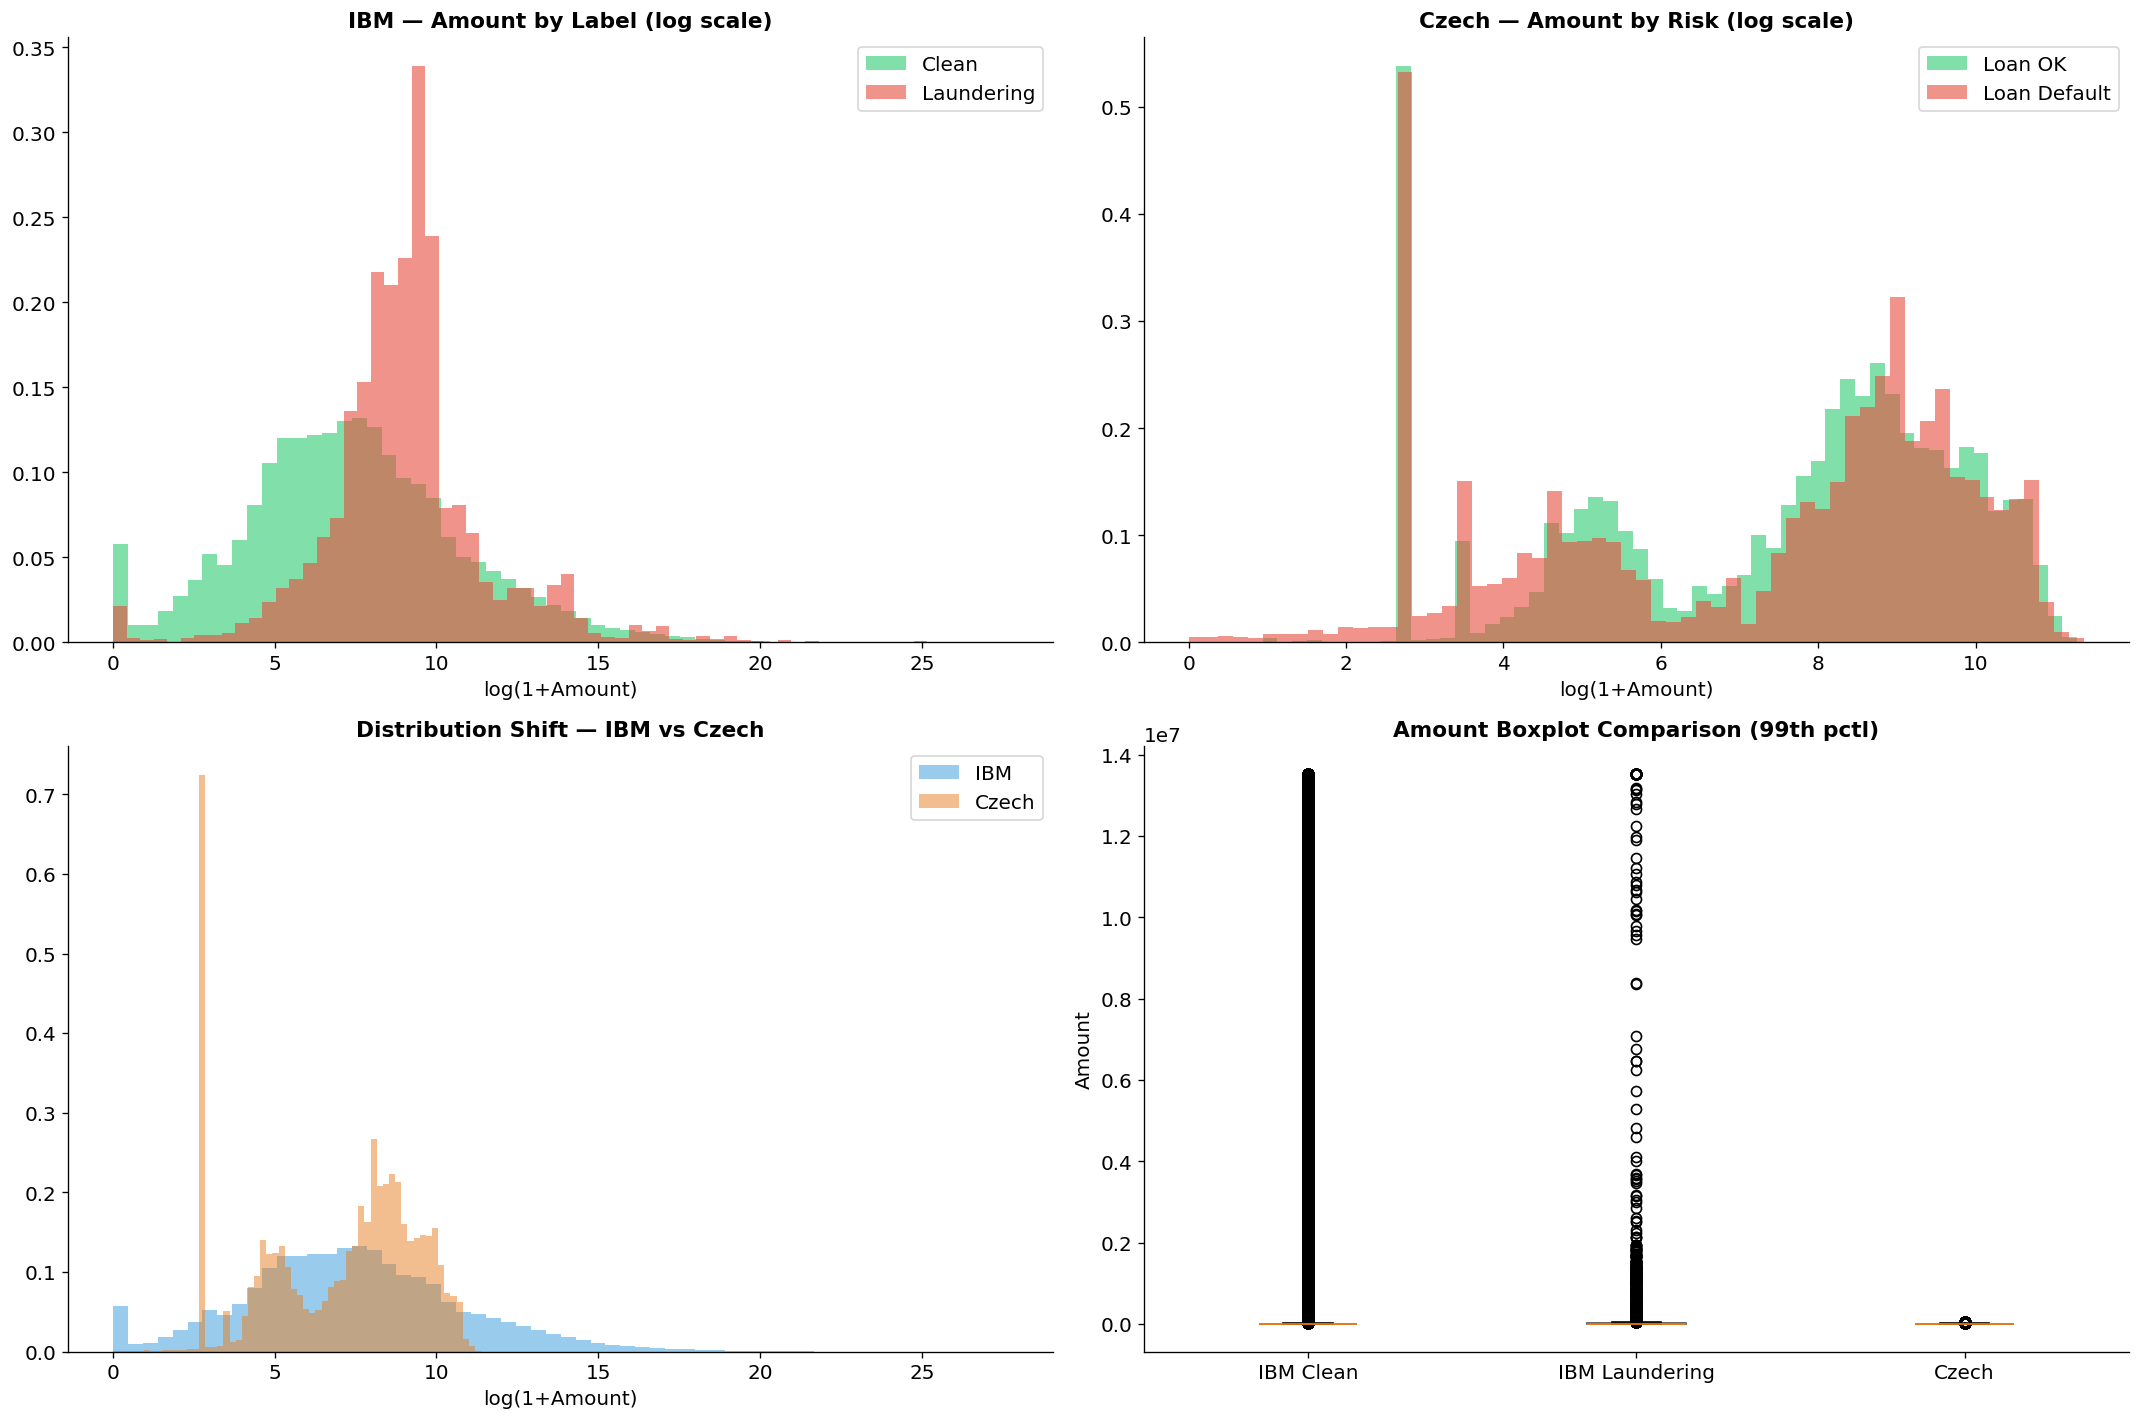

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax = axes[0,0]
ax.hist(np.log1p(ibm_d[ibm_d['_label']==0]['amount']), bins=60, alpha=0.6, color='#2ecc71', label='Clean', density=True)
ax.hist(np.log1p(ibm_d[ibm_d['_label']==1]['amount']), bins=60, alpha=0.6, color='#e74c3c', label='Laundering', density=True)
ax.set_title('IBM — Amount by Label (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1+Amount)'); ax.legend()

ax = axes[0,1]
czl = cz_d[cz_d['_label'] >= 0]
if len(czl) > 0:
    ax.hist(np.log1p(czl[czl['_label']==0]['amount']), bins=60, alpha=0.6, color='#2ecc71', label='Loan OK', density=True)
    ax.hist(np.log1p(czl[czl['_label']==1]['amount']), bins=60, alpha=0.6, color='#e74c3c', label='Loan Default', density=True)
ax.set_title('Czech — Amount by Risk (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1+Amount)'); ax.legend()

ax = axes[1,0]
ax.hist(np.log1p(ibm_d['amount'].clip(lower=0)), bins=60, alpha=0.5, color='#3498db', label='IBM', density=True)
ax.hist(np.log1p(cz_d['amount'].clip(lower=0)),  bins=60, alpha=0.5, color='#e67e22', label='Czech', density=True)
ax.set_title('Distribution Shift — IBM vs Czech', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1+Amount)'); ax.legend()

ax = axes[1,1]
data_bp = [
    ibm_d[ibm_d['_label']==0]['amount'].clip(upper=ibm_d['amount'].quantile(0.99)),
    ibm_d[ibm_d['_label']==1]['amount'].clip(upper=ibm_d['amount'].quantile(0.99)),
    cz_d['amount'].clip(upper=cz_d['amount'].quantile(0.99)),
]
bp = ax.boxplot(data_bp, labels=['IBM Clean','IBM Laundering','Czech'], patch_artist=True)
for p, c in zip(bp['boxes'], ['#2ecc71','#e74c3c','#e67e22']):
    p.set_facecolor(c); p.set_alpha(0.7)
ax.set_title('Amount Boxplot Comparison (99th pctl)', fontsize=13, fontweight='bold')
ax.set_ylabel('Amount')

plt.tight_layout()
plt.savefig('viz2_amounts.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Time Series Patterns

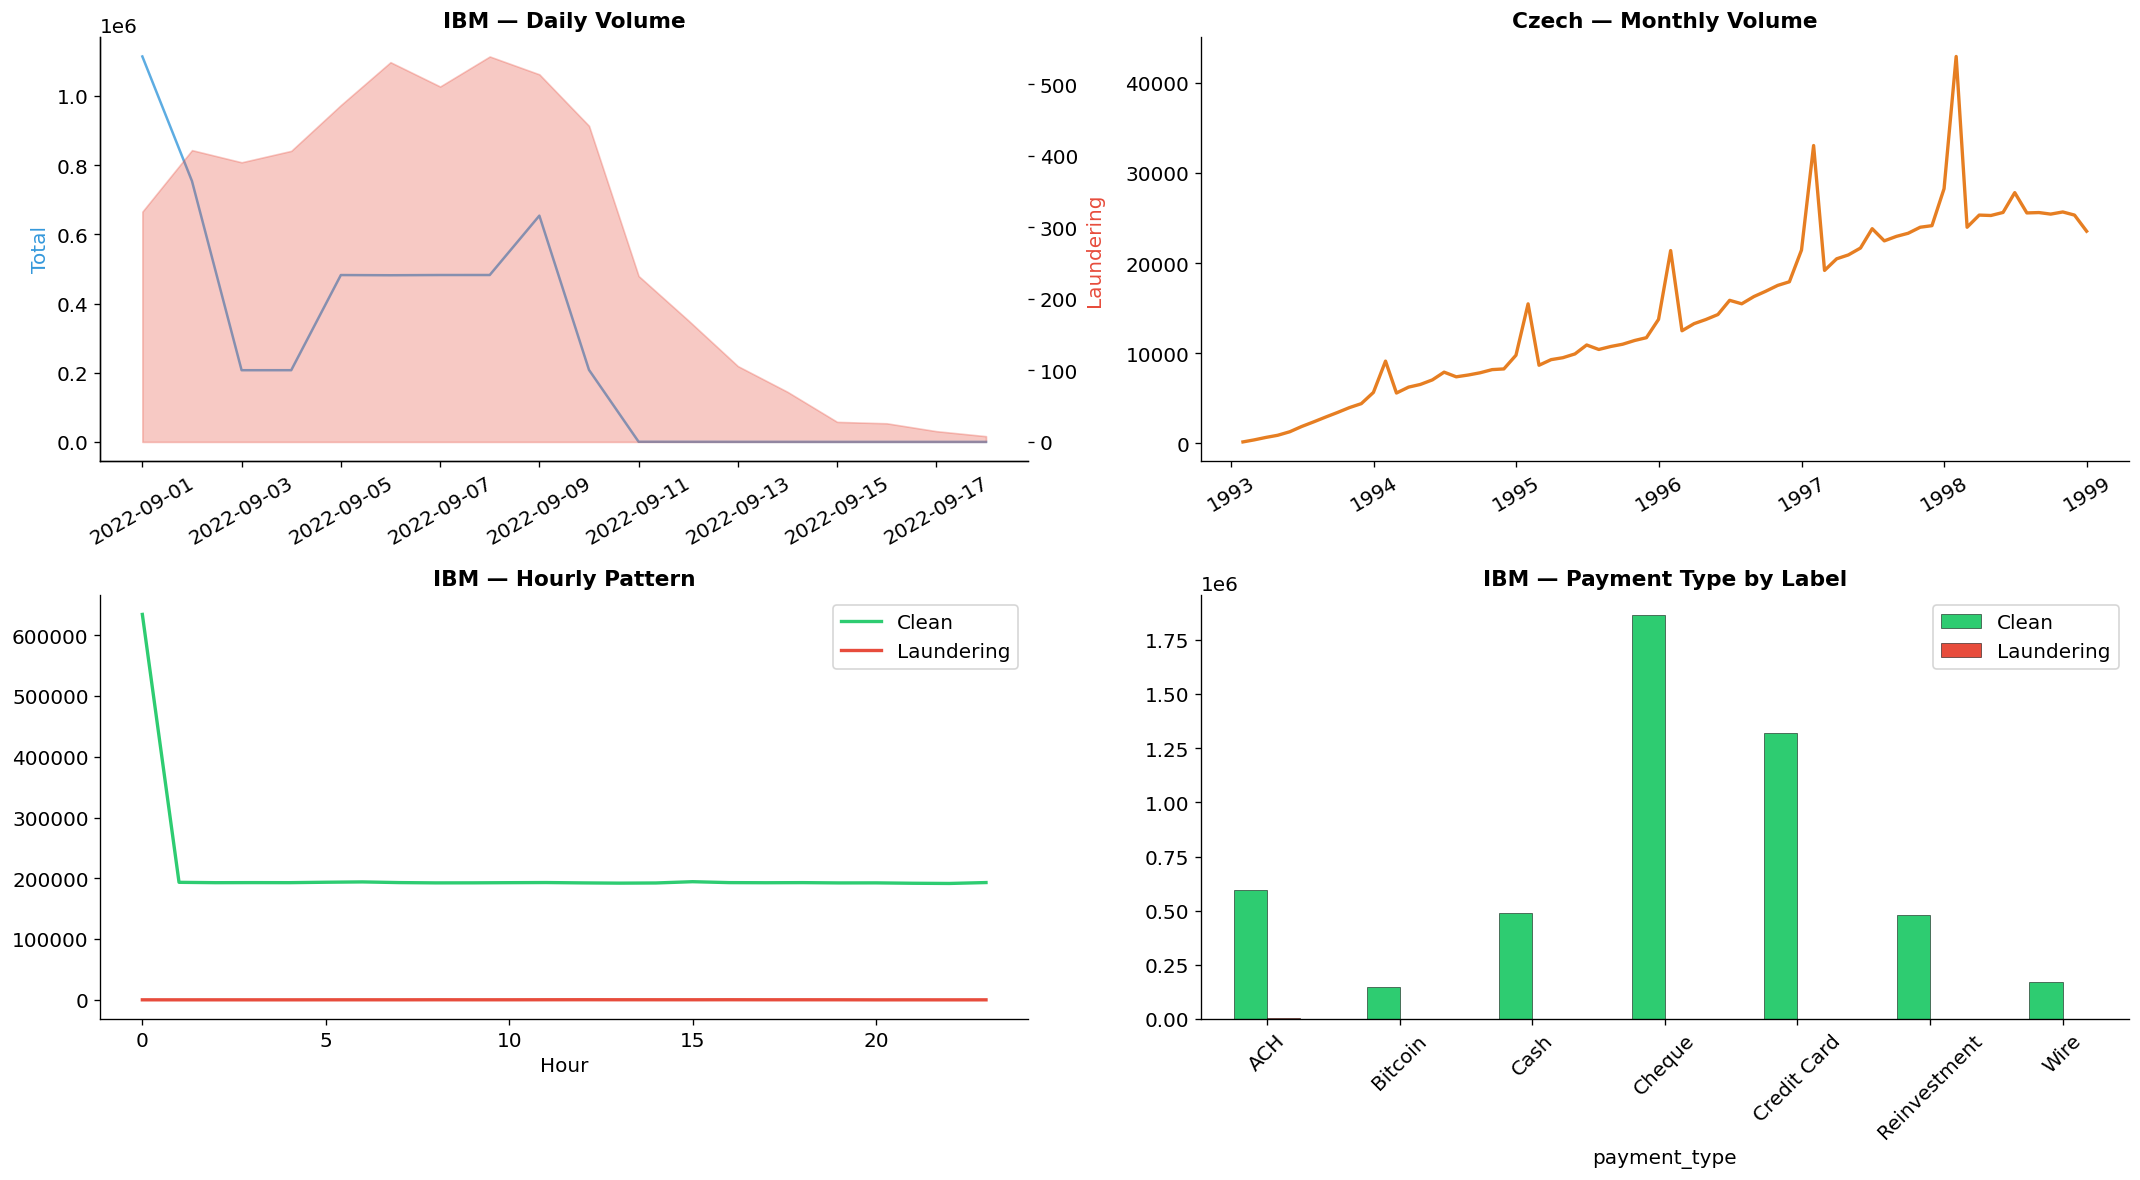

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

ax = axes[0,0]
ibm_daily = (ibm_d.set_index('timestamp')
               .resample('D')
               .agg(total=('amount','count'), launder=('_label','sum'))
               .dropna())
ax.plot(ibm_daily.index, ibm_daily['total'], color='#3498db', alpha=0.8)
ax2 = ax.twinx()
ax2.fill_between(ibm_daily.index, ibm_daily['launder'], color='#e74c3c', alpha=0.3)
ax.set_title('IBM — Daily Volume', fontsize=13, fontweight='bold')
ax.set_ylabel('Total', color='#3498db'); ax2.set_ylabel('Laundering', color='#e74c3c')
ax.tick_params(axis='x', rotation=30)

ax = axes[0,1]
cz_monthly = cz_d.dropna(subset=['timestamp']).set_index('timestamp').resample('M').size()
ax.plot(cz_monthly.index, cz_monthly.values, color='#e67e22', linewidth=2)
ax.set_title('Czech — Monthly Volume', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

ax = axes[1,0]
ibm_hourly = ibm_d.groupby([ibm_d['timestamp'].dt.hour, '_label']).size().unstack(fill_value=0)
ibm_hourly.plot(ax=ax, color=['#2ecc71','#e74c3c'], linewidth=2)
ax.set_title('IBM — Hourly Pattern', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour'); ax.legend(['Clean','Laundering'])

ax = axes[1,1]
pt = ibm_d.groupby(['payment_type', '_label']).size().unstack(fill_value=0)
pt.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black', linewidth=0.3)
ax.set_title('IBM — Payment Type by Label', fontsize=13, fontweight='bold')
ax.legend(['Clean','Laundering']); ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('viz3_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Training

In [6]:
patterns_df          = parse_ibm_patterns()
X_ibm_scaled, y_ibm, _ = build_feature_matrix(ibm_raw, patterns_df)
G_ibm                = build_transaction_graph(ibm_clean)

print(f'Feature matrix : {X_ibm_scaled.shape}')
print(f'Fraud rate     : {y_ibm.mean()*100:.3f}%')
print(f'Graph          : {G_ibm.number_of_nodes():,} nodes, {G_ibm.number_of_edges():,} edges')

Feature matrix : (5078345, 14)
Fraud rate     : 0.102%
Graph          : 41,142 nodes, 40,163 edges


In [7]:
import time

t0 = time.time(); iso, iso_scores = train_isolation_forest(X_ibm_scaled); print(f'Isolation Forest  {time.time()-t0:.1f}s')
t0 = time.time(); km,  km_scores  = train_kmeans(X_ibm_scaled);           print(f'K-Means           {time.time()-t0:.1f}s')
t0 = time.time(); ae,  ae_scores  = train_autoencoder(X_ibm_scaled, device=DEVICE); print(f'Autoencoder       {time.time()-t0:.1f}s')

ens_scores = compute_ensemble_scores(iso_scores, km_scores, ae_scores)
print('Ensemble computed.')

Isolation Forest  29.7s
K-Means           21.8s
Autoencoder       85.0s
Ensemble computed.


## 6. Evaluation Curves

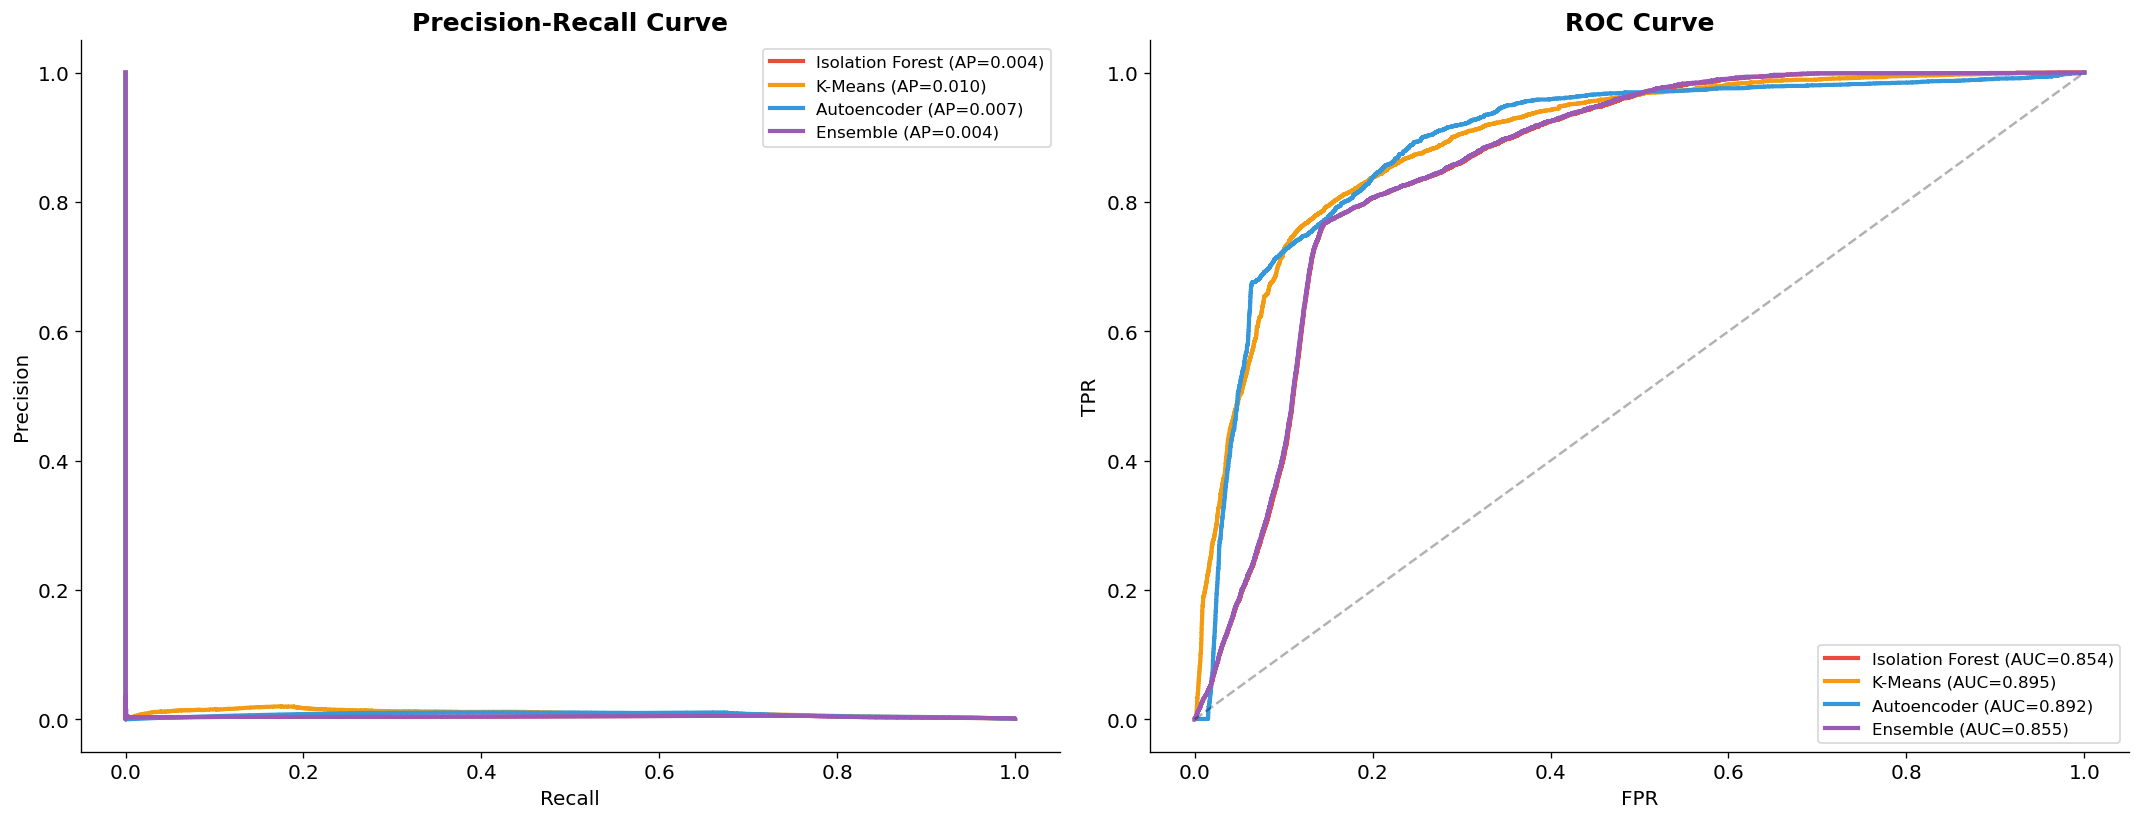

In [8]:
scores_dict = {
    'Isolation Forest': iso_scores,
    'K-Means':          km_scores,
    'Autoencoder':      ae_scores,
    'Ensemble':         ens_scores,
}

fig = plot_pr_roc_curves(scores_dict, y_ibm)
plt.savefig('eval_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. PCA Projection

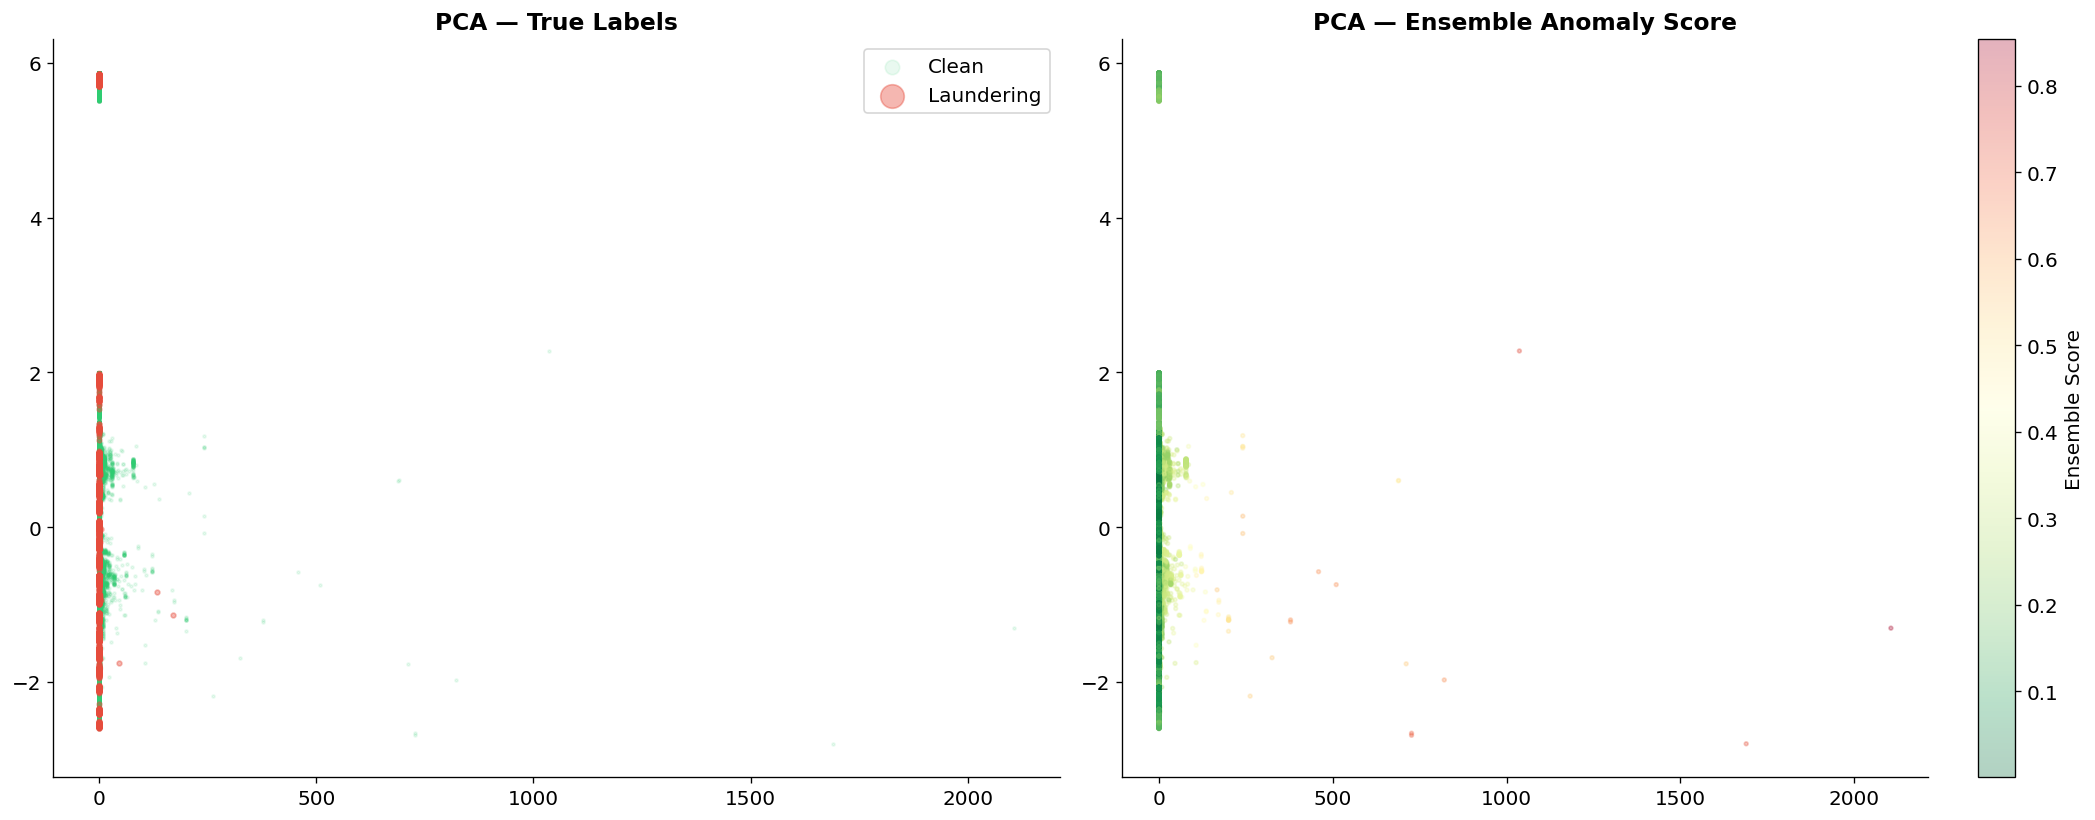

In [9]:
fig = plot_pca_projection(X_ibm_scaled, y_ibm.values, ens_scores)
plt.savefig('pca_viz.png', dpi=150, bbox_inches='tight')
plt.show()